# Spectrogram-oriented noise for anomaly maps (study notebook)

Goal: explore **Perlin-like** and **Gabor** random fields tailored to mel spectrograms before moving logic into `src/`. Gabor noise biases **orientation and elongation** to the mel–time axes (anisotropic like many acoustic events). The production path will **binarize / threshold** a continuous noise map into a binary anomaly mask.

**Design axes (maximize randomization):**

1. **Frequency** — sample one or more mel bands with **variable bandwidth** (narrow to full-span), analogous to choosing where blobs appear in 2D Perlin.
2. **Time** — sample **several segments** with **variable count and lengths** (non-overlapping by default; optional jitter), similar to the spatial variety of Perlin blobs.
3. **Within each segment** — fill **consecutive frames** with a **time process** that mixes smooth (1D Perlin / cosine envelopes), piecewise (runs, steps), and rough components so adjacent frames are correlated but not identical.

This notebook keeps all generators **self-contained** for experimentation; later we can factor the chosen recipe into a module next to `perlin.py`.

## 1. Setup

In [10]:
from __future__ import annotations

import sys
from pathlib import Path

_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as nd_rotate, zoom
from scipy.signal import fftconvolve

from src.utils.anomalies.perlin import rand_perlin_2d_np

RNG = np.random.default_rng(42)

n_mels = 128
T = 320
spectrogram_shape = (n_mels, T)

In [11]:
def anisotropic_field(T, F, time_sigma, freq_sigma):
    noise = np.random.randn(F, T)
    
    fft = np.fft.fft2(noise)
    kt = np.fft.fftfreq(T)[None, :]
    kf = np.fft.fftfreq(F)[:, None]
    
    filt = np.exp(-(kt**2 * time_sigma**2 + kf**2 * freq_sigma**2))
    field = np.fft.ifft2(fft * filt).real
    
    return field

def multiscale_field(T, F):
    field = 0
    for i, amp in enumerate([1.0, 0.5, 0.25]):
        field += amp * anisotropic_field(
            T, F,
            time_sigma=8 / (2**i),
            freq_sigma=3 / (2**i)
        )
    return field

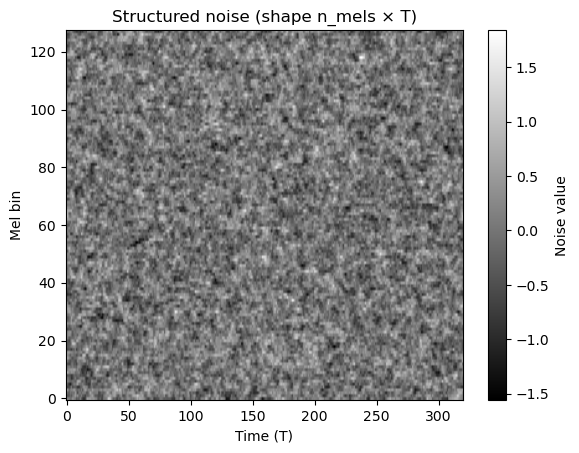

In [13]:
# Default spectral_tilt=0: tilt>0 boosts mel-DC → vertical column striping (see docstring)
noise = multiscale_field(T, n_mels)
plt.imshow(noise, cmap="gray", aspect="auto", origin="lower")
plt.xlabel("Time (T)")
plt.ylabel("Mel bin")
plt.colorbar(label="Noise value")
plt.title("Structured noise (shape n_mels × T)")
plt.show()